In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df = pd.read_excel("20240607FULL_final.xlsx", sheet_name='qf_21',index_col=0)
print(df.columns)
df.rename(columns={'Fraction of prismatic phase':'β','Fraction of basal phase':'LPSO','屈服强度':'Yield Strength','抗拉强度 （UTS）':'Tensile Strength (UTS)'},inplace= True)

In [34]:
print(df.columns)
df.rename(columns={'Fraction of prismatic phase':'β','Fraction of basal phase':'LPSO','屈服强度':'Yield Strength','抗拉强度 （UTS）':'Tensile Strength (UTS)'},inplace= True)

Index(['Length of prismatic phase', 'mean AtomicRadius', 'Zr fraction', 'β/β',
       'Width of prismatic phase', 'frac f valence electrons',
       'Diameter of prismatic phase', 'Diameter of basal phase',
       'Width of basal phase', 'Calculated Grain Boundary',
       'Interant electrons', 'Calculated Yield Strength',
       'Length of Basal phase', 'Habit Plane', 'LPSO', 'Yang omega',
       'Distribution of precipitation', 'Grain Size', 'Yield Strength',
       'Tensile Strength (UTS)', 'LPSO Bin'],
      dtype='object')


,Length of prismatic phase,mean AtomicRadius,Zr fraction,β/β,Width of prismatic phase,frac f valence electrons,Diameter of prismatic phase,Diameter of basal phase,Width of basal phase,Calculated Grain Boundary,...,Calculated Yield Strength,Length of Basal phase,Habit Plane,LPSO,Yang omega,Distribution of precipitation,Grain Size,Yield Strength,Tensile Strength (UTS),LPSO Bin
MagpieData avg_dev MeltingT,,,,,,,,,,,,,,,,,,,,,
34.914719,8.7,1.506678,0.000000,10.00,5.0,0.078602,8.7,50.0,10.0,69.060914,...,162.227111,50.0,3,4.9,2.068650,3,39.30,386,464,"[4.9, 4.95)"
36.714576,8.6,1.506549,0.000000,10.00,5.0,0.056914,8.6,50.0,10.0,62.002431,...,151.402710,50.0,3,6.7,2.262757,3,40.10,442,493,"[6.7, 6.75)"
38.606531,20.0,1.506467,0.000000,10.00,10.0,0.040407,20.0,50.0,10.0,57.869389,...,145.412261,50.0,3,7.4,2.227139,3,44.10,420,487,"[7.4, 7.45)"
47.987890,8.3,1.509229,0.000000,10.00,5.0,0.080979,8.3,50.0,10.0,115.114434,...,222.043020,50.0,3,8.8,2.009091,3,14.50,448,520,"[8.8, 8.85)"
31.450000,30.0,1.506259,0.001386,4.00,10.0,0.056204,30.0,0.0,0.0,24.683832,...,106.683007,0.0,7,0.0,2.082778,1,150.00,139,240,"[0.0, 0.05)"
38.519115,30.0,1.507563,0.001342,12.00,10.0,0.056943,30.0,0.0,0.0,32.432694,...,122.309990,0.0,7,0.0,2.023153,1,90.00,154,220,"[0.0, 0.05)"
53.260499,30.0,1.510281,0.001311,20.00,10.0,0.057791,30.0,0.0,0.0,50.296751,...,155.338573,0.0,7,0.0,1.902599,1,40.00,289,340,"[0.0, 0.05)"
11.445493,10.0,1.501428,0.000551,0.97,5.0,0.010822,10.0,0.0,0.0,41.323512,...,86.600643,0.0,7,0.0,2.755676,1,52.60,244,330,"[0.0, 0.05)"
43.818206,10.0,1.507114,0.000000,26.40,6.6,0.066328,10.0,60.0,10.0,52.857899,...,148.724167,60.0,3,10.0,3.005977,3,60.00,427,509,"[10.0, 10.05)"


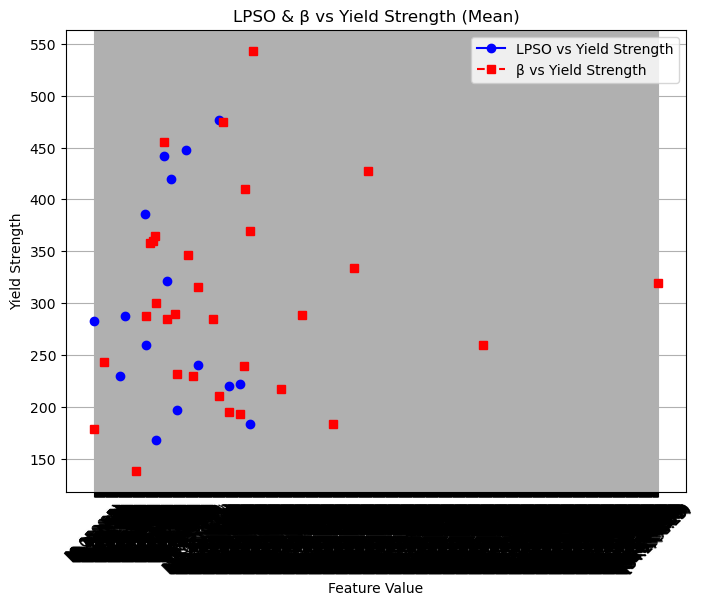

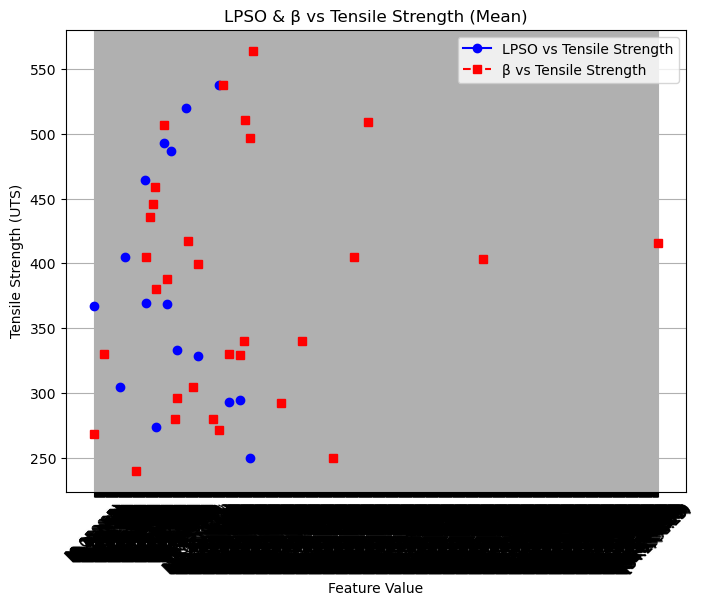

All sample data saved to Strength_Full_Samples.xlsx


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取 Excel 文件
df = pd.read_excel("20240607FULL_final.xlsx", sheet_name='qf_21', index_col=0)

# 重命名列名（确保一致）
df.rename(columns={
    'Fraction of prismatic phase': 'β',  # β/βc
    'Fraction of basal phase': 'LPSO',   # LPSO
    '屈服强度': 'Yield Strength',
    '抗拉强度 （UTS）': 'Tensile Strength (UTS)'
}, inplace=True)

# **保存完整原始数据**
output_file = "Strength_Full_Samples.xlsx"
df.to_excel(output_file, index=True)

# **定义分组区间**
bin_width = 0.05  # 设定分组间隔
df["LPSO Bin"] = pd.cut(df["LPSO"], bins=np.arange(df["LPSO"].min(), df["LPSO"].max() + bin_width, bin_width), right=False)
df["β Bin"] = pd.cut(df["β"], bins=np.arange(df["β"].min(), df["β"].max() + bin_width, bin_width), right=False)

# 计算均值
grouped_lpos_yield = df.groupby("LPSO Bin")["Yield Strength"].mean()
grouped_lpos_tensile = df.groupby("LPSO Bin")["Tensile Strength (UTS)"].mean()
grouped_beta_yield = df.groupby("β Bin")["Yield Strength"].mean()
grouped_beta_tensile = df.groupby("β Bin")["Tensile Strength (UTS)"].mean()

# **绘制 Yield Strength（屈服强度）的二维曲线**
plt.figure(figsize=(8, 6))
plt.plot(grouped_lpos_yield.index.astype(str), grouped_lpos_yield.values, marker='o', linestyle='-', color='blue', label="LPSO vs Yield Strength")
plt.plot(grouped_beta_yield.index.astype(str), grouped_beta_yield.values, marker='s', linestyle='--', color='red', label="β vs Yield Strength")
plt.xlabel("Feature Value")
plt.ylabel("Yield Strength")
plt.title("LPSO & β vs Yield Strength (Mean)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# **绘制 Tensile Strength（抗拉强度）的二维曲线**
plt.figure(figsize=(8, 6))
plt.plot(grouped_lpos_tensile.index.astype(str), grouped_lpos_tensile.values, marker='o', linestyle='-', color='blue', label="LPSO vs Tensile Strength")
plt.plot(grouped_beta_tensile.index.astype(str), grouped_beta_tensile.values, marker='s', linestyle='--', color='red', label="β vs Tensile Strength")
plt.xlabel("Feature Value")
plt.ylabel("Tensile Strength (UTS)")
plt.title("LPSO & β vs Tensile Strength (Mean)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

print("All sample data saved to Strength_Full_Samples.xlsx")
